In [1]:
print("My Data Analyst Project Started 🚀")


My Data Analyst Project Started 🚀


In [2]:
pip install pandas numpy matplotlib seaborn scikit-learn


Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd

data = pd.read_csv("retail_cleans.csv")

data.head()


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice,Year,Month,MonthYear
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4,2009,dic,2009-12-01
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009,dic,2009-12-01
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009,dic,2009-12-01
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8,2009,dic,2009-12-01
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0,2009,dic,2009-12-01


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400916 entries, 0 to 400915
Data columns (total 12 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      400916 non-null  int64  
 1   StockCode    400916 non-null  object 
 2   Description  400916 non-null  object 
 3   Quantity     400916 non-null  int64  
 4   InvoiceDate  400916 non-null  object 
 5   Price        400916 non-null  float64
 6   Customer ID  400916 non-null  int64  
 7   Country      400916 non-null  object 
 8   TotalPrice   400916 non-null  float64
 9   Year         400916 non-null  int64  
 10  Month        400916 non-null  object 
 11  MonthYear    400916 non-null  object 
dtypes: float64(2), int64(4), object(6)
memory usage: 36.7+ MB


In [5]:
data.isnull().sum()

Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
TotalPrice     0
Year           0
Month          0
MonthYear      0
dtype: int64

In [6]:
data = data.dropna()

In [7]:
data = data.drop_duplicates()

In [8]:
data['InvoiceDate'] = pd.to_datetime(data['InvoiceDate'])

In [9]:
data.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country', 'TotalPrice', 'Year', 'Month',
       'MonthYear'],
      dtype='object')

In [10]:
data.columns = data.columns.str.strip()

In [11]:
data['TotalPrice'] = data['Quantity'] * data['Price']

In [12]:
data.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice,Year,Month,MonthYear
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4,2009,dic,2009-12-01
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009,dic,2009-12-01
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009,dic,2009-12-01
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8,2009,dic,2009-12-01
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0,2009,dic,2009-12-01


In [13]:
data['TotalPrice'].sum()

np.float64(8798233.743999999)

In [14]:
print("Total Revenue:", round(data['TotalPrice'].sum(),2))

Total Revenue: 8798233.74


In [15]:
top_products = data.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

print(top_products)

Description
WHITE HANGING HEART T-LIGHT HOLDER    56814
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54610
BROCADE RING PURSE                    48166
PACK OF 72 RETRO SPOT CAKE CASES      45129
ASSORTED COLOUR BIRD ORNAMENT         44431
60 TEATIME FAIRY CAKE CASES           35656
PACK OF 60 PINK PAISLEY CAKE CASES    30871
JUMBO BAG RED RETROSPOT               29519
SMALL POPCORN HOLDER                  25703
BLACK AND WHITE PAISLEY FLOWER MUG    25685
Name: Quantity, dtype: int64


In [16]:
country_sales = data.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False)

print(country_sales.head(10))

Country
United Kingdom    7381644.433
EIRE               356041.860
Netherlands        268784.350
Germany            202025.391
France             146107.070
Sweden              53147.990
Denmark             50906.850
Spain               47568.650
Switzerland         43921.390
Australia           31446.800
Name: TotalPrice, dtype: float64


In [17]:
data['Month'] = data['InvoiceDate'].dt.to_period('M')

In [18]:
monthly_sales = data.groupby('Month')['TotalPrice'].sum()

print(monthly_sales)

Month
2009-12     683504.010
2010-01     555802.672
2010-02     504558.956
2010-03     696978.471
2010-04     591982.002
2010-05     597833.380
2010-06     636371.130
2010-07     589736.170
2010-08     602224.600
2010-09     829013.951
2010-10    1033112.010
2010-11    1166460.022
2010-12     310656.370
Freq: M, Name: TotalPrice, dtype: float64


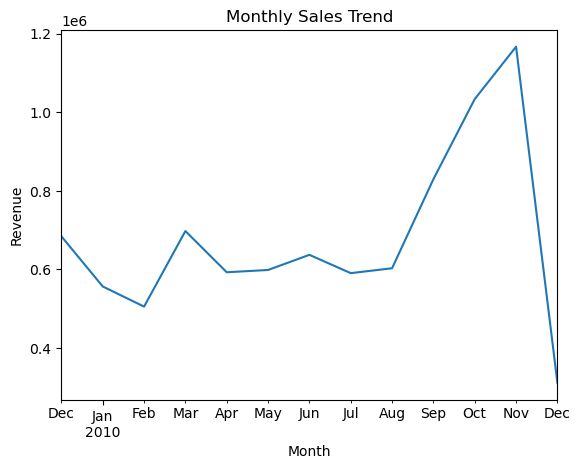

In [19]:
import matplotlib.pyplot as plt

monthly_sales.plot()

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

In [20]:
customer_data = data.groupby('Customer ID').agg({
    'TotalPrice':'sum',
    'Quantity':'sum'
}).reset_index()

customer_data.head()

,Customer ID,TotalPrice,Quantity
0,12346,372.86,70
1,12347,1323.32,828
2,12348,222.16,373
3,12349,2671.14,993
4,12351,300.93,261


In [21]:
from sklearn.cluster import KMeans

In [22]:
kmeans = KMeans(n_clusters=3)
customer_data['Segment'] = kmeans.fit_predict(customer_data[['TotalPrice','Quantity']])

In [23]:
customer_data.head()

,Customer ID,TotalPrice,Quantity,Segment
0,12346,372.86,70,0
1,12347,1323.32,828,0
2,12348,222.16,373,0
3,12349,2671.14,993,0
4,12351,300.93,261,0


In [24]:
customer_data['Segment'].value_counts()

Segment
0    4283
2      24
1       5
Name: count, dtype: int64

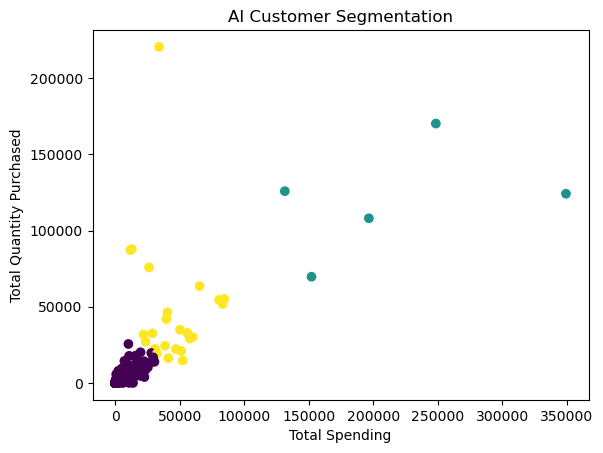

In [25]:
import matplotlib.pyplot as plt

plt.scatter(customer_data['TotalPrice'], customer_data['Quantity'], 
            c=customer_data['Segment'])

plt.title("AI Customer Segmentation")
plt.xlabel("Total Spending")
plt.ylabel("Total Quantity Purchased")

plt.show()

In [26]:
import os
os.listdir()

['.ipynb_checkpoints',
 'cleaned_ecommerce_data.csv',
 'Ecommerce_Customer_Analytics.ipynb',
 'retail_cleans.csv']

In [27]:
pip install openpyxl

Note: you may need to restart the kernel to use updated packages.


In [28]:
pip install openpyxl

Note: you may need to restart the kernel to use updated packages.


In [29]:
data.to_excel("cleaned_ecommerce_data.xlsx", engine="openpyxl", index=False)

In [30]:
data.to_csv("cleaned_ecommerce_data.csv", index=False)

In [31]:
data.to_csv("cleaned_ecommerce_data.csv", index=False)

In [32]:
data.to_csv("cleaned_ecommerce_data.csv", index=False, encoding="utf-8")

In [33]:
data.to_csv("cleaned_ecommerce_data.csv", index=False)

In [34]:
data.to_csv("cleaned_ecommerce_data.csv", index=False, encoding="utf-8")

In [1]:
import pandas as pd

# Load your dataset
df = pd.read_csv("cleaned_retail_data.csv")

# Take sample (e.g., 5000 rows)
df_sample = df.sample(n=5000, random_state=42)

# Save smaller file
df_sample.to_csv("sample_retail_data.csv", index=False)

FileNotFoundError: [Errno 2] No such file or directory: 'cleaned_retail_data.csv'